In [1]:
import json
import os
import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

EYEQ = Path("/kaggle/input/datasets/izuchukwuoruche/eyeq-512-full")     # or eyeq-512-full
IMAGES = EYEQ / "eyeq_512"

WORK = Path("/kaggle/working")
RESULTS = WORK / "results"
FIGURES = WORK / "figures"
for d in (RESULTS, FIGURES):
    d.mkdir(exist_ok=True)

CLASSES = ["Good", "Usable", "Reject"]
GOOD, USABLE, REJECT = 0, 1, 2
SEED = 42

print(sorted(p.name for p in EYEQ.iterdir()))

['eyeq_512', 'manifest_eyeq_512.csv']


In [2]:
m = pd.read_csv(EYEQ / "manifest_eyeq_512.csv")

print(m.shape)                                  # expect (28792, 7)
print(list(m.columns))
assert "eyeq_split" in m.columns, "this is the old dataset - attach v2"

print("\nby official partition:")
print(m.groupby("eyeq_split").quality.value_counts().unstack())

counts = m.patient_id.value_counts()
print(f"\npatients: {m.patient_id.nunique():,}")
print(f"eyes per patient: {counts.value_counts().sort_index().to_dict()}")
print(f"mean: {len(m) / m.patient_id.nunique():.2f}")
print(f"images in a correlated pair: {(counts == 2).sum() * 2:,} "
      f"({(counts == 2).sum() * 2 / len(m):.0%})")

assert counts.max() <= 2, \
    "a patient cannot have more than two eyes - check patient_id extraction"

(28792, 7)
['stem', 'image', 'quality', 'patient_id', 'eye', 'eyeq_split', 'path']

by official partition:
quality        0     1     2
eyeq_split                  
test        8471  4558  3220
train       8347  1876  2320

patients: 20,662
eyes per patient: {1: 12532, 2: 8130}
mean: 1.39
images in a correlated pair: 16,260 (56%)


In [3]:
from sklearn.model_selection import GroupShuffleSplit


def split_official(df, val_frac=0.18, seed=SEED, drop_overlap=False):
    """Honour EyeQ's published train/test partition, then carve a validation
    set out of train - grouped by patient.

    val_frac=0.18 leaves ~10,285 training images against the 12,543 that
    published methods used. Note the difference in the report.

    drop_overlap: only needed if cell A6 found patients spanning EyeQ's
    train/test boundary. Removes them from test to give a leak-free variant.
    """
    df = df.copy().reset_index(drop=True)
    df["split"] = np.where(df.eyeq_split == "test", "test", "train")

    if drop_overlap:
        spread = df.groupby("patient_id")["eyeq_split"].nunique()
        bad = set(spread[spread > 1].index)
        if bad:
            n = df[(df.split == "test") & (df.patient_id.isin(bad))].shape[0]
            df = df[~((df.split == "test") & (df.patient_id.isin(bad)))]
            print(f"dropped {n} test images from {len(bad)} overlapping patients")

    tr = df[df.split == "train"]
    gss = GroupShuffleSplit(n_splits=1, test_size=val_frac, random_state=seed)
    _, val_i = next(gss.split(tr, groups=tr.patient_id))
    df.loc[tr.index[val_i], "split"] = "val"
    return df.reset_index(drop=True)


def verify_splits(df):
    """Raise if any patient spans splits. Call this every single time."""
    spread = df.groupby("patient_id")["split"].nunique()
    bad = spread[spread > 1]
    if not bad.empty:
        raise AssertionError(
            f"{len(bad)} patients in more than one split, "
            f"e.g. {list(bad.index[:5])}")

    missing = {"train", "val", "test"} - set(df["split"].unique())
    if missing:
        raise AssertionError(f"missing splits: {missing}")

    print(f"verified: {df.patient_id.nunique():,} patients, no leakage")
    return True

In [4]:
m = split_official(m)
verify_splits(m)

print(m.split.value_counts().to_dict())
print()
print(pd.crosstab(m.split, m.quality, normalize="index").round(3))

m.to_csv(WORK / "manifest_split.csv", index=False)

verified: 20,662 patients, no leakage
{'test': 16249, 'train': 10264, 'val': 2279}

quality      0      1      2
split                       
test     0.521  0.281  0.198
train    0.662  0.152  0.186
val      0.680  0.139  0.181


In [5]:
from sklearn.metrics import (accuracy_score, cohen_kappa_score,
                             confusion_matrix, f1_score,
                             precision_recall_fscore_support)


def three_class_report(y_true, y_pred):
    """Everything reported for three-class gradability. JSON-serialisable."""
    p, r, f1, n = precision_recall_fscore_support(
        y_true, y_pred, labels=range(3), zero_division=0)

    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        # quadratic weighting penalises Good->Reject far harder than
        # Good->Usable, matching how a clinician reads an ordered scale
        "kappa": float(cohen_kappa_score(y_true, y_pred, weights="quadratic")),
        "per_class": {
            c: {"precision": float(p[i]), "recall": float(r[i]),
                "f1": float(f1[i]), "n": int(n[i])}
            for i, c in enumerate(CLASSES)
        },
        "confusion": confusion_matrix(y_true, y_pred, labels=range(3)).tolist(),
    }


def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, seed=0):
    """Resample with replacement; report the middle 95%.

    On a 16,249-image test set these intervals will be tight - that is the
    main practical gain from using the official partition.
    """
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rng, n = np.random.default_rng(seed), len(y_true)

    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], y_pred[idx]))

    lo, hi = np.percentile(scores, [2.5, 97.5])
    return float(metric_fn(y_true, y_pred)), float(lo), float(hi)

In [6]:
import datetime


def record(name, params, metrics, code_version="", notes=""):
    """Write results/<name>.json. Commit these to the repo - tiny, diffable,
    and the record of what you actually measured.

    No git SHA: there is no repo inside the Kaggle session. Bump code_version
    by hand when the approach changes.
    """
    payload = {
        "name": name,
        "when": datetime.datetime.now().isoformat(timespec="seconds"),
        "code_version": code_version,
        "params": params,
        "metrics": metrics,
        "notes": notes,
    }
    (RESULTS / f"{name}.json").write_text(json.dumps(payload, indent=2))
    print(f"recorded {name}")
    return payload


def plot_confusion(cm, path, title=""):
    """Row-normalised confusion matrix with counts and percentages."""
    cm = np.asarray(cm)
    cmn = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    fig, ax = plt.subplots(figsize=(5, 4.4))
    ax.imshow(cmn, cmap="Oranges", vmin=0, vmax=1)
    ax.set_xticks(range(3), CLASSES)
    ax.set_yticks(range(3), CLASSES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    if title:
        ax.set_title(title, fontsize=11)

    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{cm[i, j]}\n{cmn[i, j]:.0%}",
                    ha="center", va="center", fontsize=9,
                    color="white" if cmn[i, j] > 0.5 else "black")

    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()

In [7]:
from sklearn.dummy import DummyClassifier

train = m[m.split == "train"]
val = m[m.split == "val"]
test = m[m.split == "test"]

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(train[["quality"]], train.quality)          # X is ignored

rep_maj = three_class_report(test.quality, dummy.predict(test[["quality"]]))
record("w5-majority", {"strategy": "most_frequent",
                       "split": "eyeq-official"}, rep_maj,
       code_version="wk5-v1")

print(f"accuracy {rep_maj['accuracy']:.3f}   macro_f1 {rep_maj['macro_f1']:.3f}")
print("\ntest set class balance:")
print(test.quality.value_counts(normalize=True).sort_index().round(3).to_dict())

recorded w5-majority
accuracy 0.521   macro_f1 0.228

test set class balance:
{0: 0.521, 1: 0.281, 2: 0.198}


In [8]:
FEATURE_NAMES = ["lap_var", "tenengrad", "mean", "std",
                 "clip_low", "clip_high", "illum_cv", "green_std"]


def features(img):
    """img: RGB uint8, 512x512 from the cached dataset. Returns 8 scalars."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > 7                      # retina only, not the black padding
    f = {}

    # ---- SHARPNESS ----------------------------------------------------
    # Laplacian variance: high on crisp edges, near zero on blur.
    # The classic blur detector and still hard to beat.
    f["lap_var"] = float(cv2.Laplacian(gray, cv2.CV_64F).var())

    # Tenengrad: gradient energy. A second opinion on focus that responds
    # differently to sensor noise than the Laplacian does.
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    f["tenengrad"] = float(np.mean(gx ** 2 + gy ** 2))

    # ---- EXPOSURE -----------------------------------------------------
    v = gray[mask]
    f["mean"] = float(v.mean())
    f["std"] = float(v.std())
    f["clip_low"] = float((v < 15).mean())       # crushed shadows
    f["clip_high"] = float((v > 240).mean())     # blown highlights

    # ---- ILLUMINATION EVENNESS ----------------------------------------
    # An eyelid or bad flash angle darkens one region. Compare quadrant
    # means; uneven lighting shows as high relative spread.
    h, w = gray.shape
    quads = [gray[:h // 2, :w // 2], gray[:h // 2, w // 2:],
             gray[h // 2:, :w // 2], gray[h // 2:, w // 2:]]
    qm = [q[q > 7].mean() if (q > 7).any() else 0.0 for q in quads]
    f["illum_cv"] = float(np.std(qm) / (np.mean(qm) + 1e-6))

    # ---- COLOUR -------------------------------------------------------
    # The green channel carries most retinal vessel contrast, so its spread
    # is a cheap proxy for structural visibility.
    f["green_std"] = float(img[:, :, 1][mask].std())

    return f

In [9]:
def load(stem):
    img = cv2.imread(str(IMAGES / f"{stem}.png"))
    if img is None:
        raise IOError(f"cannot read {stem}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def extract(sub):
    return pd.DataFrame([features(load(s)) for s in tqdm(sub.stem)])


X_tr, y_tr = extract(train), train.quality.values
X_va, y_va = extract(val), val.quality.values
X_te, y_te = extract(test), test.quality.values

# cache - you will retrain many times and re-extracting wastes an hour
X_tr.to_parquet(WORK / "feat_train.parquet")
X_va.to_parquet(WORK / "feat_val.parquet")
X_te.to_parquet(WORK / "feat_test.parquet")

print(X_tr.shape, X_va.shape, X_te.shape)
print(X_tr.describe().T[["mean", "std", "min", "max"]].round(2))
assert not X_tr.isna().any().any(), "NaNs in features"

  0%|          | 0/10264 [00:00<?, ?it/s]

  0%|          | 0/2279 [00:00<?, ?it/s]

  0%|          | 0/16249 [00:00<?, ?it/s]

(10264, 8) (2279, 8) (16249, 8)
              mean     std   min      max
lap_var      80.61   59.28  1.72   488.47
tenengrad  1611.37  996.05  5.72  9534.52
mean        101.61   31.95  8.00   246.44
std          26.57    9.48  0.00    87.43
clip_low      0.01    0.06  0.00     1.00
clip_high     0.00    0.02  0.00     0.94
illum_cv      0.12    0.08  0.00     1.73
green_std    25.54    9.67  0.00    88.51


In [10]:
import lightgbm as lgb

clf = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=SEED,
    verbose=-1,
)
clf.fit(X_tr, y_tr, eval_set=[(X_va, y_va)])

LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=400,
               random_state=42, verbose=-1)

clip_low     5322
mean         5127
lap_var      5045
tenengrad    4678
green_std    4626
illum_cv     4613
std          4496
clip_high    2093
dtype: int32


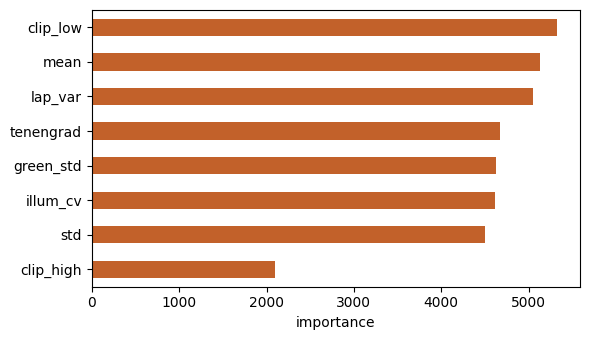

In [11]:
imp = pd.Series(clf.feature_importances_,
                index=X_tr.columns).sort_values(ascending=False)
print(imp)

imp.sort_values().plot.barh(figsize=(6, 3.5), color="#C2612A")
plt.xlabel("importance")
plt.tight_layout()
plt.savefig(FIGURES / "feature_importance.png", dpi=150)
plt.show()

accuracy  0.710   95% CI [0.703, 0.718]
macro F1  0.657
kappa     0.674

{
  "Good": {
    "precision": 0.7897191308956015,
    "recall": 0.8795891866367607,
    "f1": 0.8322350050262481,
    "n": 8471
  },
  "Usable": {
    "precision": 0.5672837800497375,
    "recall": 0.45041684949539273,
    "f1": 0.5021401491989728,
    "n": 4558
  },
  "Reject": {
    "precision": 0.6378716744913928,
    "recall": 0.632919254658385,
    "f1": 0.635385814497272,
    "n": 3220
  }
}


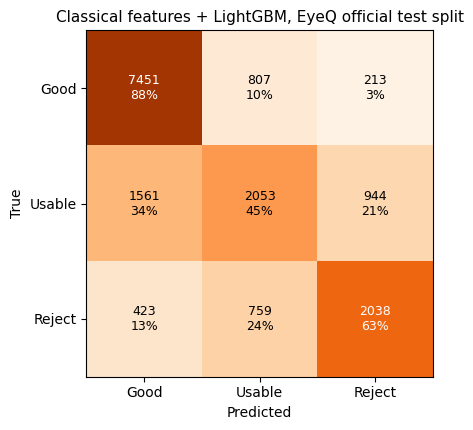

recorded w5-classical-lgbm


{'name': 'w5-classical-lgbm',
 'when': '2026-09-18T04:54:37',
 'code_version': 'wk5-v1',
 'params': {'n_features': 8,
  'n_estimators': 400,
  'learning_rate': 0.05,
  'class_weight': 'balanced',
  'split': 'eyeq-official',
  'n_train': 10264,
  'n_test': 16249,
  'seed': 42},
 'metrics': {'accuracy': 0.7103206351160072,
  'macro_f1': 0.6565869895741643,
  'kappa': 0.6739449291502031,
  'acc_ci': [0.7033632838943935, 0.7175210782201982],
  'per_class': {'Good': {'precision': 0.7897191308956015,
    'recall': 0.8795891866367607,
    'f1': 0.8322350050262481,
    'n': 8471},
   'Usable': {'precision': 0.5672837800497375,
    'recall': 0.45041684949539273,
    'f1': 0.5021401491989728,
    'n': 4558},
   'Reject': {'precision': 0.6378716744913928,
    'recall': 0.632919254658385,
    'f1': 0.635385814497272,
    'n': 3220}}},
 'notes': "Eight hand-crafted features on EyeQ's published test partition. Frangi vessel filter dropped for speed."}

In [12]:
y_pred = clf.predict(X_te)
rep = three_class_report(y_te, y_pred)
acc, lo, hi = bootstrap_ci(y_te, y_pred, accuracy_score)

print(f"accuracy  {acc:.3f}   95% CI [{lo:.3f}, {hi:.3f}]")
print(f"macro F1  {rep['macro_f1']:.3f}")
print(f"kappa     {rep['kappa']:.3f}")
print()
print(json.dumps(rep["per_class"], indent=2))

plot_confusion(rep["confusion"], FIGURES / "confusion_classical.png",
               title="Classical features + LightGBM, EyeQ official test split")

record("w5-classical-lgbm",
       {"n_features": len(X_tr.columns), "n_estimators": 400,
        "learning_rate": 0.05, "class_weight": "balanced",
        "split": "eyeq-official", "n_train": len(X_tr), "n_test": len(X_te),
        "seed": SEED},
       {**{k: rep[k] for k in ["accuracy", "macro_f1", "kappa"]},
        "acc_ci": [lo, hi], "per_class": rep["per_class"]},
       code_version="wk5-v1",
       notes="Eight hand-crafted features on EyeQ's published test partition. "
             "Frangi vessel filter dropped for speed.")

In [13]:
cm = np.array(rep["confusion"])
danger = cm[2, 0] / cm[2].sum()
print(f"Reject misread as Good: {cm[2, 0]}/{cm[2].sum()} ({danger:.1%})")

Reject misread as Good: 423/3220 (13.1%)


In [14]:
rows = []
for f in sorted(RESULTS.glob("*.json")):
    d = json.loads(f.read_text())
    rows.append({"model": d["name"],
                 "accuracy": d["metrics"]["accuracy"],
                 "macro_f1": d["metrics"]["macro_f1"]})

print(pd.DataFrame(rows).to_markdown(index=False, floatfmt=".3f"))

| model             |   accuracy |   macro_f1 |
|:------------------|-----------:|-----------:|
| w5-classical-lgbm |      0.710 |      0.657 |
| w5-majority       |      0.521 |      0.228 |


In [15]:
shutil.rmtree(WORK / ".virtual_documents", ignore_errors=True)

print(sorted(p.name for p in WORK.iterdir()))
print(sorted(p.name for p in RESULTS.iterdir()))
print(sorted(p.name for p in FIGURES.iterdir()))

['__notebook__.ipynb', 'feat_test.parquet', 'feat_train.parquet', 'feat_val.parquet', 'figures', 'manifest_split.csv', 'results']
['w5-classical-lgbm.json', 'w5-majority.json']
['confusion_classical.png', 'feature_importance.png']
